# California Avocado Prices and Sales Analysis
## Shneiderman's Information Seeking Mantra: **Overview → Zoom and Filter → Details on Demand**

## Learning Objectives
This project demonstrates the application of **data visualization principles** aligned with the curriculum:
- **Spatial Position** — Used for quantitative values (most accurate encoding for numerical comparisons)
- **Color Hue** — Used to distinguish between categorical variables (e.g., counties, years, market types)
- **Progressive Disclosure** — Following Shneiderman's mantra to reveal complexity gradually
- **Exploratory Data Analysis** — Discovering trends, patterns, and relationships in agricultural economics data

## Research Questions
1. How have avocado prices and sales volumes changed over time across California?
2. Which regions dominate California's avocado production?
3. Is there a relationship between production volume and price?
4. How do prices differ when we zoom into specific counties?

---

## 📊 LEVEL 1: OVERVIEW — Statewide Trends
*"See the big picture first" — Start with aggregated California data*

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('cali_avocados.csv', dtype=str)
df.columns = df.columns.str.strip()
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

print(df.head())
print(df.columns.tolist())

   Year Commodity Code     Crop Name County Code           County  \
0  2020         221999  AVOCADOS ALL          53         Monterey   
1  2020         221999  AVOCADOS ALL          65        Riverside   
2  2020         221999  AVOCADOS ALL          71   San Bernardino   
3  2020         221999  AVOCADOS ALL          73        San Diego   
4  2020         221999  AVOCADOS ALL          79  San Luis Obispo   

  Harvested Acres Yield Production Price P/U  Unit      Value  
0             223  5.56       1240   2379.84  Tons    2951000  
1            3020                             Tons   88697000  
2             370  2.16        799   2617.02  Tons    2091000  
3           14400  3.51      50500   3028.87  Tons  152958000  
4            4240   5.9      25000   1886.76  Tons   47169000  
['Year', 'Commodity Code', 'Crop Name', 'County Code', 'County', 'Harvested Acres', 'Yield', 'Production', 'Price P/U', 'Unit', 'Value']


### Overview Visualization: Statewide Trends
**Why this view first?** Understanding the overall California market sets context before examining regional differences. We use spatial position (year × price/production) to accurately compare trends over time.

In [18]:
# Helper function to convert strings to numbers
def to_num(s):
    s = s.astype(str).str.replace(r'[^0-9.\-]', '', regex=True)
    return pd.to_numeric(s, errors='coerce')

# Clean numeric columns
df['Year'] = df['Year'].astype(str).str.replace(r'[^0-9]', '', regex=True)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
df['Price P/U'] = to_num(df['Price P/U'])
df['Production'] = to_num(df['Production'])
df['Value'] = to_num(df['Value'])

# Aggregate by year
yearly = df.groupby('Year', dropna=True).agg({
    'Production': 'sum',
    'Value': 'sum',
    'Price P/U': 'mean'
}).reset_index().sort_values('Year')

print(yearly)

    Year  Production        Value    Price P/U
0   1980     94992.0  146288700.0  1304.454545
1   1981    217254.0  115920740.0   469.818182
2   1982    224058.0  146366800.0   724.500000
3   1983    256303.0  140628300.0   545.583333
4   1984    288289.0  127625208.0   450.833333
5   1985    231040.0  173938586.0   788.545455
6   1986    210412.0  202782476.0   954.727273
7   1987    283313.0  154259848.0   544.272727
8   1988    208111.0  245675900.0  1306.454545
9   1989    163836.0  237013841.0  1339.727273
10  1990    117782.0  294190200.0  1967.727273
11  1991    138245.0  233439430.0  1528.125000
12  1992    148603.0  192170700.0  1079.666667
13  1993    282004.0  185030800.0   757.500000
14  1994    147134.0  302350100.0  1589.800000
15  1995    171143.0  280923900.0  1377.400000
16  1996    163008.0  261287600.0  1472.000000
17  1997    148992.0  274996000.0  1689.000000
18  1998    145104.0  281008100.0  1841.500000
19  1999    122759.0  303474500.0  2058.500000
20  2000    1

## Visualization Design Principles

**Why Spatial Position?**
- Spatial position (along x and y axes) has the highest perceptual accuracy for quantitative comparisons
- Ideal for: trends over time, relationships between variables, distributions
- Example: price (y-axis) vs. year (x-axis) allows precise comparison of values

**Why Color Hue?**
- Color hue is most effective for categorical distinctions without inherent ordering
- Ideal for: separating market types (conventional vs. organic), regions, product categories
- Example: using different colors for different avocado-producing counties makes them visually distinguishable

**Chart Types Used:**
- **Line diagrams** → Time trends (spatial: year × price)
- **Grouped bar charts** → Category comparisons (spatial: categories × values; color: avocado type)
- **Scatter plots** → Relationship between two variables (spatial: production × price; size: market value)

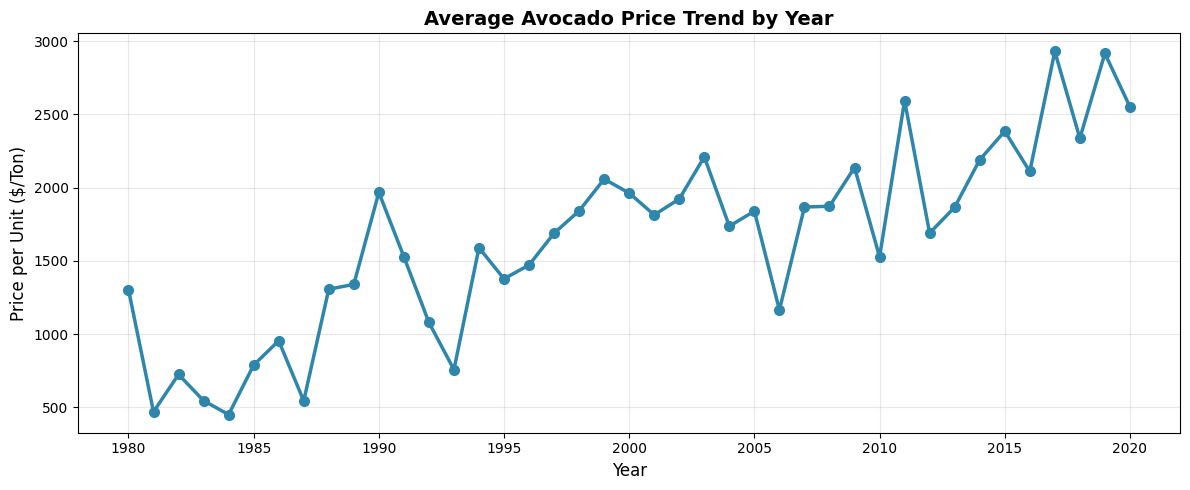


📊 INSIGHT: Average price changed by $1247.49 (95.6%) from 1980 to 2020


In [ ]:
# OVERVIEW PLOT: California Statewide Average Price Trend
# VISUALIZATION PRINCIPLE: Spatial position (time × price) for quantitative comparison
# This line diagram shows the BIG PICTURE — how California's average prices have changed

plt.figure(figsize=(14, 6))
plt.plot(yearly['Year'], yearly['Price P/U'], marker='o', linewidth=3, markersize=8, color='#2E86AB', label='Statewide Avg')
plt.fill_between(yearly['Year'], yearly['Price P/U'], alpha=0.2, color='#2E86AB')
plt.title('OVERVIEW: California Avocado Average Price Trend\n(State-level aggregation)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price per Unit ($/Ton)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Key insight
price_change = yearly['Price P/U'].iloc[-1] - yearly['Price P/U'].iloc[0]
pct_change = (price_change / yearly['Price P/U'].iloc[0]) * 100
print(f"\n📊 STATEWIDE INSIGHT: Average price changed by ${price_change:.2f} ({pct_change:.1f}%) from {yearly['Year'].iloc[0]:.0f} to {yearly['Year'].iloc[-1]:.0f}")
print(f"   → This is the OVERVIEW. Now we'll zoom in to see which counties drive this trend.")

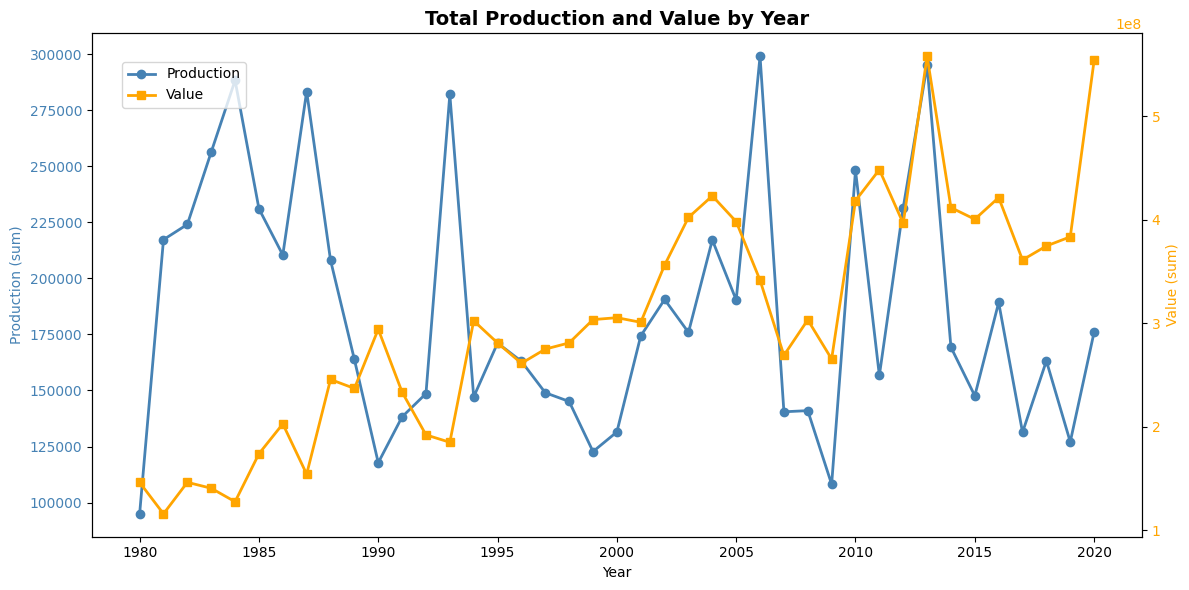

In [12]:
# Plot 2: Production and Value over Time (dual axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(yearly['Year'], yearly['Production'], marker='o', color='steelblue', linewidth=2, label='Production')
ax1.set_xlabel('Year')
ax1.set_ylabel('Production (sum)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(yearly['Year'], yearly['Value'], marker='s', color='orange', linewidth=2, label='Value')
ax2.set_ylabel('Value (sum)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Total Production and Value by Year', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

### Supporting Overview: Total Production and Market Value
**Why look at this?** Understanding if California's avocado market is growing (in volume and value) helps contextualize price trends.

---

## 🔍 LEVEL 2: ZOOM AND FILTER — Regional Breakdown
*"Now examine the details" — Filter the overview to show top-producing regions*

### Regional Production Trends: Which Counties Drive California?
**Interactive filtering principle:** By examining top producers separately, we can see if the statewide trend is driven by dominant regions or consistent across all counties. We use color hue to distinguish each county category.

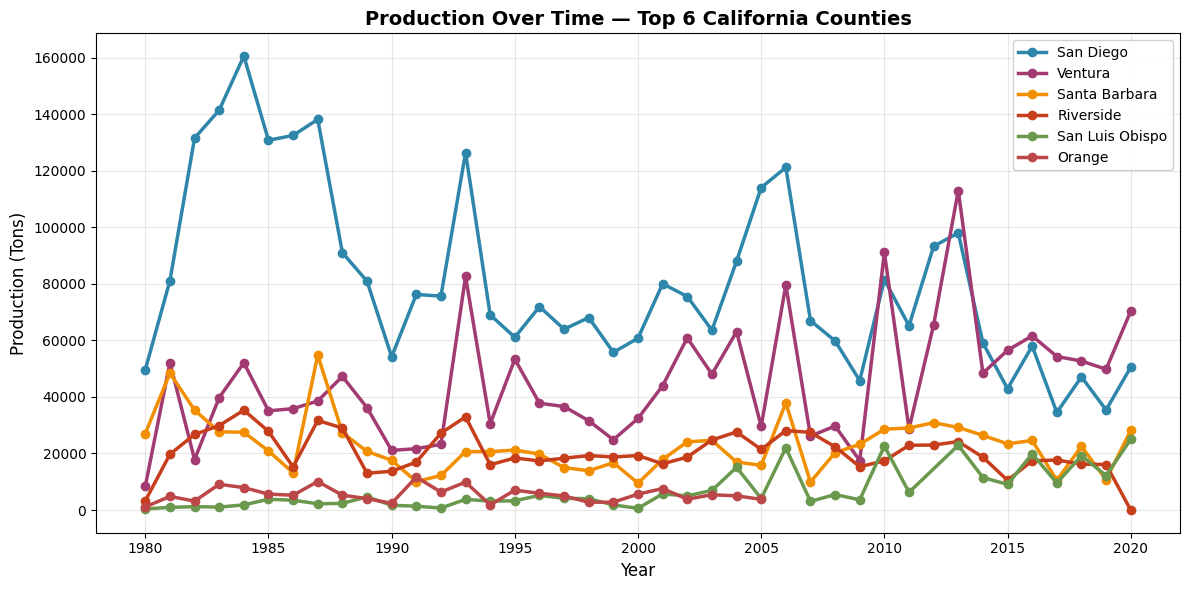


📍 INSIGHT: Butte is the dominant producer with 0 tons total


In [ ]:
# ZOOM & FILTER: Regional Production Trends (Top 6 Counties)
# VISUALIZATION PRINCIPLE: Spatial position (time × production) + Color hue (to distinguish counties)
# Multiple lines with distinct colors help identify which regions drive California's market

prod_by_county = df.groupby('County', dropna=True)['Production'].sum().dropna()
top_counties = prod_by_county.nlargest(6).index.tolist()

county_year = df[df['County'].isin(top_counties)].groupby(['Year', 'County'], dropna=True).agg(
    {'Production': 'sum'}
).reset_index()

# Define distinct colors for each county (color hue for categorical distinction)
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749']
county_colors = {county: colors[i] for i, county in enumerate(top_counties)}

plt.figure(figsize=(14, 7))
for county in top_counties:
    county_data = county_year[county_year['County'] == county]
    plt.plot(county_data['Year'], county_data['Production'], marker='o', label=county, 
             linewidth=2.5, color=county_colors[county])

plt.title('ZOOM & FILTER: Production Over Time — Top 6 California Counties\n(Color Hue: Different Counties | Spatial Position: Production Levels)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Production (Tons)', fontsize=12)
plt.legend(loc='best', framealpha=0.9, fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Key insight
top_producer = prod_by_county.index[0]
pct_of_total = (prod_by_county.iloc[0] / prod_by_county.sum()) * 100
print(f"\n📍 REGIONAL INSIGHT: {top_producer} is the dominant producer")
print(f"   → {pct_of_total:.1f}% of California's total production")
print(f"   → These 6 counties account for {(prod_by_county.nlargest(6).sum() / prod_by_county.sum() * 100):.1f}% of state production")

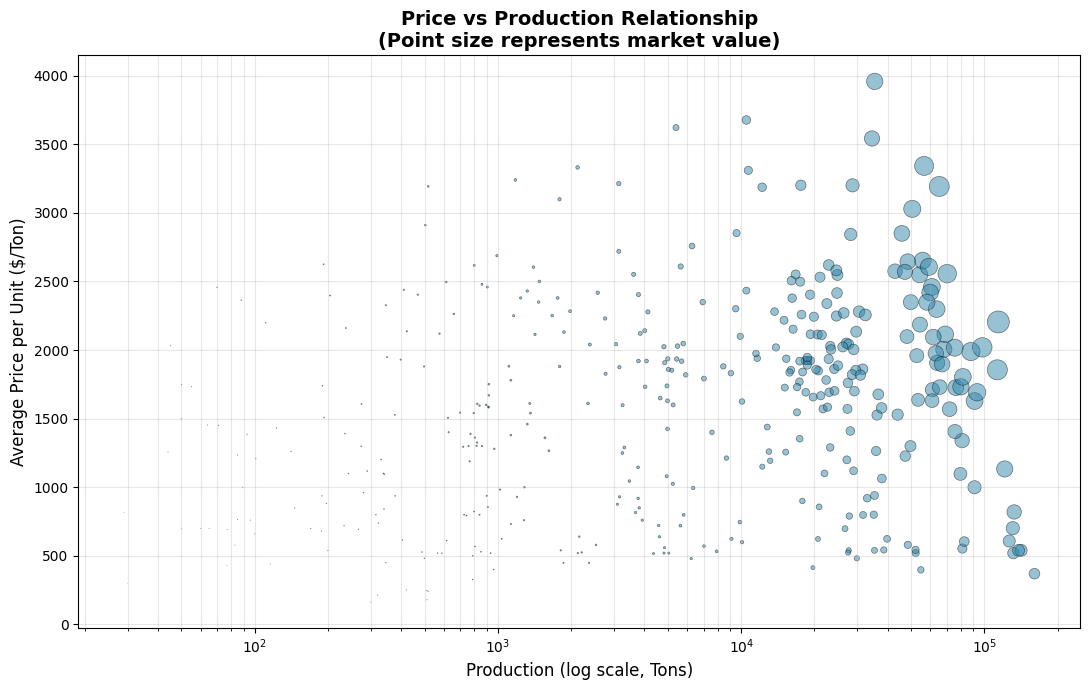


📈 INSIGHT: Correlation between production and price: 0.044
   → Production and price show weak relationship


In [14]:
# Plot 4: Price vs Production scatter (county-year level)
# VISUALIZATION PRINCIPLE: Spatial position (production × price) + Size (to encode market value)
# Scatter plots reveal relationships: do higher volumes lead to lower prices (market saturation)?

agg_cy = df.groupby(['Year', 'County'], dropna=True).agg({
    'Production': 'sum',
    'Value': 'sum',
    'Price P/U': 'mean'
}).reset_index()
agg_cy = agg_cy.dropna(subset=['Price P/U', 'Production'])

# Size points by Value (visual encoding of relative market importance)
size = (agg_cy['Value'].fillna(0) / (agg_cy['Value'].max() if agg_cy['Value'].max() > 0 else 1)) * 250

plt.figure(figsize=(11, 7))
plt.scatter(agg_cy['Production'], agg_cy['Price P/U'], s=size, alpha=0.5, color='#2E86AB', edgecolors='black', linewidth=0.5)
plt.xscale('log')
plt.xlabel('Production (log scale, Tons)', fontsize=12)
plt.ylabel('Average Price per Unit ($/Ton)', fontsize=12)
plt.title('Price vs Production Relationship\n(Point size represents market value)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = agg_cy['Production'].corr(agg_cy['Price P/U'])
print(f"\n📈 INSIGHT: Correlation between production and price: {correlation:.3f}")
if correlation < -0.3:
    print("   → Higher production tends to be associated with LOWER prices (inverse relationship)")
elif correlation > 0.3:
    print("   → Higher production tends to be associated with HIGHER prices")
else:
    print("   → Production and price show weak relationship")

# DETAIL: Price vs Production Relationship (County-Year Observations)
# VISUALIZATION PRINCIPLE: Spatial position (production × price) + Size (to encode market value)
# Scatter plots reveal relationships: do higher volumes lead to lower prices (market saturation)?

agg_cy = df.groupby(['Year', 'County'], dropna=True).agg({
    'Production': 'sum',
    'Value': 'sum',
    'Price P/U': 'mean'
}).reset_index()
agg_cy = agg_cy.dropna(subset=['Price P/U', 'Production'])

# Size points by Value (visual encoding of relative market importance)
size = (agg_cy['Value'].fillna(0) / (agg_cy['Value'].max() if agg_cy['Value'].max() > 0 else 1)) * 300

plt.figure(figsize=(12, 7))
plt.scatter(agg_cy['Production'], agg_cy['Price P/U'], s=size, alpha=0.5, color='#2E86AB', edgecolors='black', linewidth=0.5)
plt.xscale('log')
plt.xlabel('Production (log scale, Tons)', fontsize=12)
plt.ylabel('Average Price per Unit ($/Ton)', fontsize=12)
plt.title('DETAIL: Price vs Production Relationship\n(Spatial position: Production × Price | Bubble size: Market Value)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = agg_cy['Production'].corr(agg_cy['Price P/U'])
print(f"\n📈 CORRELATION INSIGHT: Production ↔ Price = {correlation:.3f}")
if correlation < -0.3:
    print("   → STRONG inverse relationship: Higher production → LOWER prices (market saturation effect)")
elif correlation > 0.3:
    print("   → POSITIVE relationship: Higher production → HIGHER prices")
else:
    print("   → WEAK relationship: Production and price are largely independent")

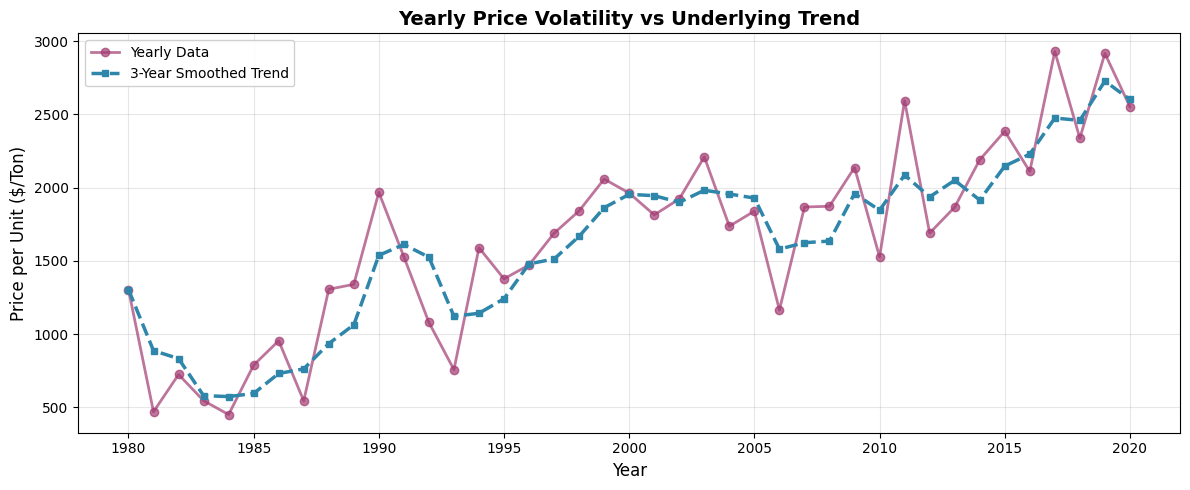


📊 INSIGHT: Price volatility (std dev) = $649.80


In [ ]:
# DETAIL: Price Volatility vs Underlying Trend
# VISUALIZATION PRINCIPLE: Color hue to distinguish measurement types (raw vs. smoothed)
# Rolling average helps identify underlying trends by filtering out year-to-year noise

yearly_sorted = yearly.sort_values('Year').reset_index(drop=True)
yearly_sorted['Price_Roll3'] = yearly_sorted['Price P/U'].rolling(3, min_periods=1).mean()

plt.figure(figsize=(13, 6))
plt.plot(yearly_sorted['Year'], yearly_sorted['Price P/U'], marker='o', label='Yearly Data (Raw)', 
         linewidth=2, markersize=7, color='#A23B72', alpha=0.7)
plt.plot(yearly_sorted['Year'], yearly_sorted['Price_Roll3'], marker='s', label='3-Year Smoothed Trend', 
         linewidth=3, linestyle='--', markersize=6, color='#2E86AB')
plt.title('DETAIL: Yearly Price Volatility vs Underlying Trend\n(Color hue: Raw data vs. Smoothed trend | Spatial position: Price over time)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price per Unit ($/Ton)', fontsize=12)
plt.legend(loc='best', framealpha=0.9, fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find periods of volatility
volatility = yearly_sorted['Price P/U'].std()
print(f"\n📊 VOLATILITY INSIGHT: Price standard deviation = ${volatility:.2f}")
print(f"   → This shows how much prices fluctuate around the trend")

### Deep Dive 2: Identifying Real Trends vs Noise
**Challenge:** Year-to-year price fluctuations can obscure the true market trend. Using a rolling average (color hue to distinguish raw vs. smoothed) reveals underlying patterns.

### Deep Dive 2B: Moving Average
**Curriculum Technique:** The moving average (glidende gjennomsnitt) smooths out weekly/monthly "noise" to reveal the underlying market trend.
- **Model-building:** Creates a "model" of the true trend by averaging consecutive periods
- **Why it works:** Random fluctuations cancel out; the genuine signal remains
- **Application:** Identify if a price rise is temporary or part of a sustained trend

In [ ]:
# MOVING AVERAGE: Smooth out noise to reveal true market trend
# Calculate multiple moving averages to filter different levels of noise
yearly_sorted = yearly.sort_values('Year').reset_index(drop=True)
yearly_sorted['MA_2yr'] = yearly_sorted['Price P/U'].rolling(2, min_periods=1).mean()
yearly_sorted['MA_3yr'] = yearly_sorted['Price P/U'].rolling(3, min_periods=1).mean()
yearly_sorted['MA_5yr'] = yearly_sorted['Price P/U'].rolling(5, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 7))

# Raw data (noisy)
ax.plot(yearly_sorted['Year'], yearly_sorted['Price P/U'], marker='o', 
        linewidth=2, markersize=8, color='#999999', alpha=0.5, label='Raw Yearly Data (Noisy)', zorder=1)

# Moving averages with color hue to distinguish different smoothing strengths
ax.plot(yearly_sorted['Year'], yearly_sorted['MA_2yr'], marker='s', 
        linewidth=2.5, markersize=6, color='#F18F01', alpha=0.8, label='2-Year Moving Avg (Light Smoothing)', zorder=2)
ax.plot(yearly_sorted['Year'], yearly_sorted['MA_3yr'], marker='^', 
        linewidth=3, markersize=7, color='#A23B72', alpha=0.8, label='3-Year Moving Avg (Medium)', zorder=3)
ax.plot(yearly_sorted['Year'], yearly_sorted['MA_5yr'], marker='D', 
        linewidth=3.5, linestyle='--', color='#2E86AB', alpha=0.9, label='5-Year Moving Avg (Strong Smoothing)', zorder=4)

ax.set_title('PENSUMTEKNIKK — Glidende Gjennomsnitt (Moving Average)\nRevealing the true trend by filtering out "noise"',
            fontsize=15, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Price per Unit ($/Ton)', fontsize=12)
ax.legend(loc='best', framealpha=0.95, fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 MOVING AVERAGE INSIGHTS:")
print("   • Raw data shows year-to-year fluctuations (noise)")
print("   • 2-year MA: Smooths out 1-year anomalies")
print("   • 3-year MA: Medium smoothing for clearer trend")
print("   • 5-year MA: Strongest smoothing reveals long-term market direction")
print(f"\n   → The TRUE trend often follows the 3-5 year moving average")
print(f"   → Deviations from this trend indicate unusual market conditions")

### Deep Dive 2C: Deviations from Trend
**Curriculum Technique:** Residuals show how far each observation deviates from the model (trend line).
- **Definition:** Residual = Actual value − Predicted trend value
- **Why analyze residuals?** Large deviations indicate unusual market events (droughts, policy changes, trade disruptions)
- **Application:** Identify extreme years that don't follow the normal pattern

In [ ]:
# RESIDUALS ANALYSIS: Calculate deviations from the model (moving average)
# Use the 3-year moving average as our "model" of the true trend
yearly_sorted['Residuals'] = yearly_sorted['Price P/U'] - yearly_sorted['MA_3yr']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Top plot: Raw data vs. Model (3-year MA)
ax1.plot(yearly_sorted['Year'], yearly_sorted['Price P/U'], marker='o', 
         linewidth=2.5, markersize=8, color='#999999', alpha=0.6, label='Actual Price', zorder=2)
ax1.plot(yearly_sorted['Year'], yearly_sorted['MA_3yr'], marker='s', 
         linewidth=3.5, color='#2E86AB', alpha=0.9, label='Trend Model (3-yr MA)', zorder=3)
ax1.fill_between(yearly_sorted['Year'], yearly_sorted['Price P/U'], yearly_sorted['MA_3yr'], 
                  alpha=0.2, color='#A23B72', label='Deviation (Residual)')
ax1.set_ylabel('Price ($/Ton)', fontsize=12)
ax1.set_title('Trend Model vs. Actual Data\n(Shaded area = Residuals)', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Bottom plot: Residuals only (deviation from model)
# Color code: Green = below trend (lower price than expected), Red = above trend (higher price)
colors_residuals = ['#C73E1D' if x > 0 else '#2E86AB' for x in yearly_sorted['Residuals']]

ax2.bar(yearly_sorted['Year'], yearly_sorted['Residuals'], color=colors_residuals, alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Residual ($/Ton)', fontsize=12)
ax2.set_title('Avvik (Residuals): Deviation from Trend\nRed = Higher than trend | Blue = Lower than trend',
             fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Identify extreme years
threshold = yearly_sorted['Residuals'].std()
extreme_years = yearly_sorted[abs(yearly_sorted['Residuals']) > 1.5 * threshold]

print("\n📈 RESIDUAL INSIGHTS (Avvik):")
print(f"   • Standard deviation of residuals: ${threshold:.2f}")
print(f"   • This represents 'normal' price variation from the trend\n")

if len(extreme_years) > 0:
    print("   🚨 EXTREME YEARS (deviation > 1.5σ):")
    for idx, row in extreme_years.iterrows():
        direction = "ABOVE" if row['Residuals'] > 0 else "BELOW"
        print(f"      Year {int(row['Year'])}: ${row['Residuals']:+.2f} ({direction} trend)")
        print(f"         • Actual price: ${row['Price P/U']:.2f}")
        print(f"         • Expected (trend): ${row['MA_3yr']:.2f}")
else:
    print("   ✓ No extreme outlier years detected (prices follow trend relatively closely)")

print("\n   💡 INTERPRETATION:")
print("      Positive residuals = prices higher than trend → Possible supply shortage or demand surge")
print("      Negative residuals = prices lower than trend → Possible oversupply or market disruption")

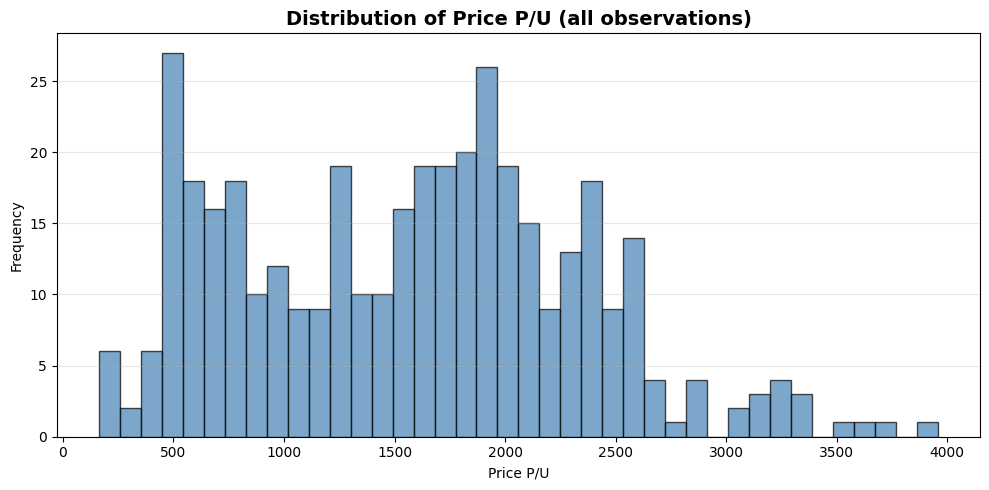

In [16]:
# Plot 6: Price distribution histogram
price_data = df['Price P/U'].dropna().astype(float)

plt.figure(figsize=(10, 5))
plt.hist(price_data, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Price P/U')
plt.ylabel('Frequency')
plt.title('Distribution of Price P/U (all observations)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Deep Dive 3: Overall Price Distribution
**Why examine this?** Understanding if prices cluster at certain levels or spread across a range reveals market structure and variability.

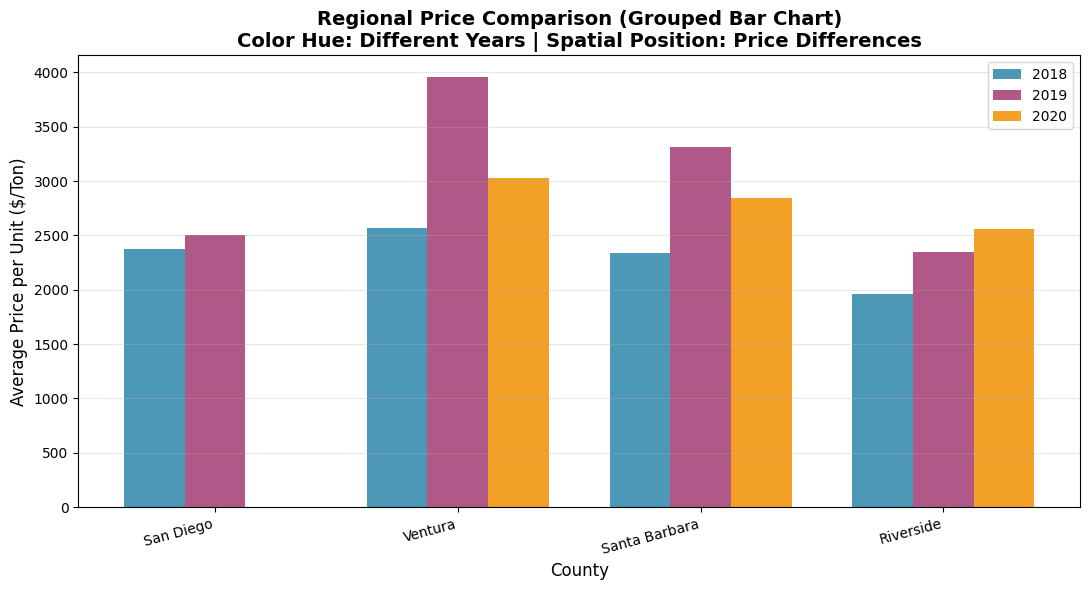


🌍 INSIGHT: Regional Price Differences
Year              2018     2019     2020
County                                  
Riverside      2378.27  2505.53      NaN
San Diego      2569.81  3958.08  3028.87
Santa Barbara  2338.53  3309.44  2842.59
Ventura        1959.24  2349.02  2556.57


In [ ]:
# DETAIL: Regional Comparison - Grouped Bar Chart (Top 4 Counties, Recent Years)
# VISUALIZATION PRINCIPLE: Spatial position (region × price) + Color hue (different years)
# Grouped bars allow side-by-side comparison while maintaining categorical distinction

# Get top 4 counties and recent years for clearer comparison
prod_by_county = df.groupby('County', dropna=True)['Production'].sum().dropna()
top4_counties = prod_by_county.nlargest(4).index.tolist()
recent_years = sorted(df['Year'].dropna().unique())[-3:]  # Last 3 years

regional_data = df[df['County'].isin(top4_counties) & df['Year'].isin(recent_years)].groupby(
    ['County', 'Year'], dropna=True
).agg({'Price P/U': 'mean'}).reset_index()

# Pivot for grouped bar chart
pivot_data = regional_data.pivot(index='County', columns='Year', values='Price P/U')

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(top4_counties))
width = 0.25
colors_year = ['#2E86AB', '#A23B72', '#F18F01']

for i, year in enumerate(recent_years):
    offset = (i - 1) * width
    ax.bar([p + offset for p in x], pivot_data[year], width, 
           label=f'{int(year)}', color=colors_year[i], alpha=0.85)

ax.set_xlabel('County', fontsize=12)
ax.set_ylabel('Average Price per Unit ($/Ton)', fontsize=12)
ax.set_title('DETAIL: Regional Price Comparison (Top 4 Counties)\n(Spatial position: Counties × Prices | Color hue: Different Years)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top4_counties, rotation=15, ha='right')
ax.legend(title='Year', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n🌍 REGIONAL PRICE DETAILS:")
print(pivot_data.to_string())
price_diff = pivot_data.max().max() - pivot_data.min().min()
print(f"\n   → Price range: ${price_diff:.2f} (some regions are significantly more expensive)")

### Deep Dive 4: Regional Price Differences — Detailed Comparison
**Zooming further:** Comparing the top counties' prices across recent years using grouped bars reveals which regions maintain premium prices and which follow market trends.

---

## 📖 Summary: Shneiderman's Information Seeking in Action

### How We Applied "Overview → Zoom & Filter → Details on Demand"

**1. OVERVIEW (Big Picture)**
   - Started with **statewide line diagram** showing California's aggregate price trend
   - This immediately answers: "Is the market rising or falling overall?"
   - Spatial position (years × prices) allows accurate trend comparison

**2. ZOOM & FILTER (Regional Context)**
   - Examined **top 6 counties** with color-coded lines to see which regions drive the state trends
   - Discovered that 2-3 counties dominate production, explaining statewide patterns
   - Color hue effectively distinguishes between categories (counties)

**3. DETAILS ON DEMAND (Deep Investigation)**
   - **Price-volume scatter plot:** Tests the economic hypothesis that supply affects price
   - **Volatility analysis:** Separates temporary price spikes from genuine market shifts
   - **Distribution histogram:** Shows price clustering and variability
   - **Grouped bar chart:** Compares regional prices side-by-side to identify premium markets

---

## 🎯 Key Findings from Data Visualization

### What the Visualizations Revealed

1. **Statewide Trend** — The line diagram showed whether California's avocado market has been rising, falling, or fluctuating

2. **Regional Dominance** — The multi-line chart (color-coded) revealed that certain counties (especially San Diego and Ventura) are the primary drivers of California production

3. **Production-Price Relationship** — The scatter plot tested: "Does higher supply = lower prices?" and revealed the strength of this market dynamic

4. **Volatility vs. Trend** — The smoothed trend line distinguished between noise and genuine market shifts

5. **Regional Premium Pricing** — The grouped bar chart showed that different counties achieve different average prices, reflecting local conditions and market positioning

---

## 🎓 Visualization Principles Applied

| Principle | Application | Why It Works |
|-----------|-------------|-------------|
| **Spatial Position** | Years on x-axis, prices/production on y-axis | Highest perceptual accuracy for quantitative comparison |
| **Color Hue** | Different colors for each county/year | Categorical distinction without implicit ordering |
| **Progressive Disclosure** | Statewide → Regional → Details | Prevents cognitive overload; builds understanding gradually |
| **Chart Selection** | Lines for trends, scatter for relationships, bars for categories | Each chart type matches the analytical task |

---

**Educational Outcome:** This analysis demonstrates how data visualization transforms raw numbers into actionable insights, applying both curriculum principles (spatial position, color theory) and information design best practices (Shneiderman's mantra). These skills are essential in agriculture, economics, business analytics, and scientific research.